In [59]:
import json
import numpy as np

kT = 4.11
beta = 1 / kT

with open('20250123_TalinR3_Ramps_5pN_JSON 2.Json') as f:
    data = json.load(f)

work_list = []
z_list = []

for pulse_key in data:
    pulse = data[pulse_key]
    z = np.array(pulse['z'])
    force = np.array(pulse['force'])
    
    z_rel = z - np.min(z)

    work = 0
    for i in range(10, len(force) - 1):
        if force[i+1] > 19.0:
            break
        deltaF = force[i+1] - force[i]
        work += z_rel[i] * deltaF
    z_list.append(z_rel[i])    #array non il valore
    work_list.append(work)

print("Work (one value per pulse, z relativa):", work_list)


Work (one value per pulse, z relativa): [610.51310814195, 559.7844170609987, 558.3851965180779, 506.9212836272166, 633.9969211345172, 609.5209655336853, 588.2119793964254, 496.3483458678175, 545.251227283223, 543.2755911751769, 542.3248028018288, 620.5533314875677, 584.463593889694, 614.0421402071452, 633.0471725951431, 580.015269149788, 568.2503977235925, 563.2598406154086, 583.4095486094894, 560.3163549484028, 564.5581790559703, 644.8991983999377, 615.0588732002675, 586.5303876708798, 570.1055978109357, 565.5396806220058, 616.2166547722436, 559.7056852784139, 564.2425834936621, 521.7783404429243, 509.89561218364474, 560.3228121673719, 643.1307179644048, 593.4368974905965, 597.3694333907066, 623.3098436770117, 551.2888806173612, 590.0630642531046, 598.4482433074336, 633.9292033361694, 596.8298330448165, 589.8826109749452, 608.1171126240969, 659.339917295842, 531.1733992603479, 546.4918957288729, 532.5734338690502, 581.5223666764787, 535.0586231960837, 609.129390585774, 572.74056164864

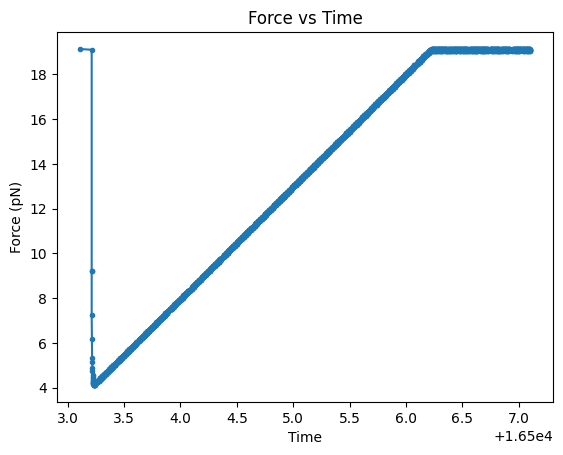

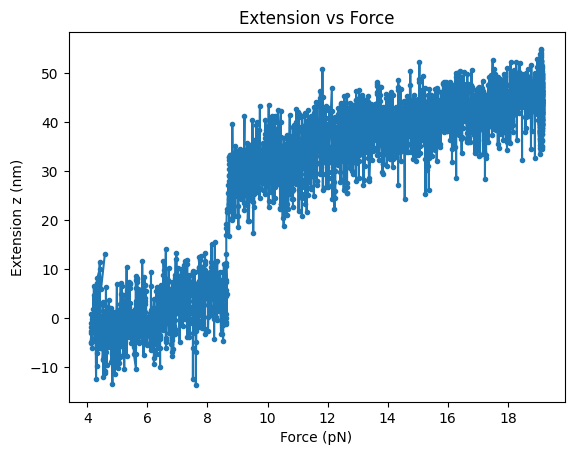

In [28]:
plt.plot(pulse['time'], pulse['force'], marker='.')
plt.xlabel('Time')
plt.ylabel('Force (pN)')
plt.title('Force vs Time')
plt.show()

plt.plot(pulse['force'][10:], pulse['z'][10:], marker='.')
plt.xlabel('Force (pN)')
plt.ylabel('Extension z (nm)')
plt.title('Extension vs Force')
plt.show()


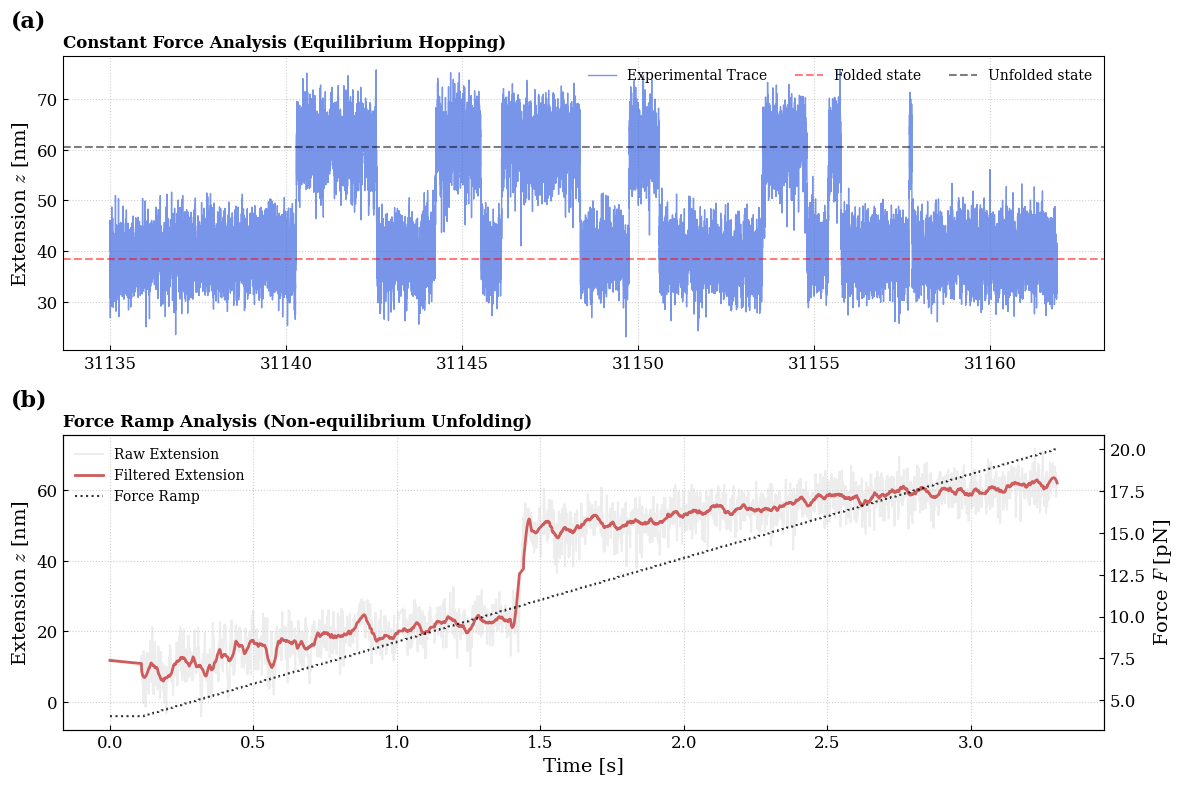

In [23]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 1. CARICAMENTO DATI
# Dati Constant Force (da TXT)
data_const = np.loadtxt("Talin_fragment.txt", skiprows=1)
t_c = data_const[:, 0]
x_c = data_const[:, 1]
peaks = [38.40, 60.48] # Stati Folded/Unfolded

# Dati Force Ramp (da JSON)
file_path = '20250411_R3_5pNs_ramps_1.Json'
with open(file_path, 'r') as f:
    data_ramp = json.load(f)
pulse = data_ramp["Pulse_Number_0"]
f_r = np.array(pulse["force"])
z_r = np.array(pulse["z"])
t_r = np.array(pulse["time"]) - pulse["time"][0]
z_r_smth = savgol_filter(z_r, 51, 3)

# 2. CONFIGURAZIONE PLOT PROFESSIONALE
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'mathtext.fontset': 'cm'
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# --- PANNELLO (a): CONSTANT FORCE ---
# Plottiamo una finestra significativa per vedere i salti (hopping)
start, end = 870_000, 900_000 
ax1.plot(t_c[start:end], x_c[start:end], color='royalblue',linewidth =1, alpha=0.7, label='Experimental Trace')
ax1.axhline(y=peaks[0], color='red', linestyle='--', linewidth=1.5, alpha=0.5,label='Folded state')
ax1.axhline(y=peaks[1], color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='Unfolded state')

ax1.set_ylabel('Extension $z$ [nm]')
ax1.set_title('Constant Force Analysis (Equilibrium Hopping)', loc='left', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', frameon=False, ncol=3)
ax1.text(-0.05, 1.1, "(a)", transform=ax1.transAxes, fontsize=16, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- PANNELLO (b): FORCE RAMP ---
# Usiamo un doppio asse per mostrare Forza e Estensione insieme
ax2_f = ax2.twinx()
ln1 = ax2.plot(t_r, z_r, color='lightgray', alpha=0.4, label='Raw Extension')
ln2 = ax2.plot(t_r, z_r_smth, color='indianred', linewidth=2, label='Filtered Extension')
ln3 = ax2_f.plot(t_r, f_r, color='black', linestyle=':', alpha=0.8, label='Force Ramp')

ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Extension $z$ [nm]')
ax2_f.set_ylabel('Force $F$ [pN]')
ax2.set_title('Force Ramp Analysis (Non-equilibrium Unfolding)', loc='left', fontsize=12, fontweight='bold')

# Unione delle legende per il pannello (b)
lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax2.legend(lns, labs, loc='upper left', frameon=False)

ax2.text(-0.05, 1.1, "(b)", transform=ax2.transAxes, fontsize=16, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('Ramp_and_Constant_Force_Analysis.pdf')
plt.show()